# Importing basic packages

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split as tts
from sklearn.metrics import classification_report,accuracy_score,confusion_matrix

import warnings
warnings.filterwarnings('ignore')
#shiva

# Import data set

In [10]:
data=pd.read_csv("diabetes.csv")

In [11]:
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


# Exploratory data analysis

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [164]:
data.describe().T.style.background_gradient(cmap = "viridis")
#shiva

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,4.494673,2.975395,1.000000,2.000000,4.494673,6.000000,17.000000
Glucose,768.000000,121.686763,30.435949,44.000000,99.750000,117.000000,140.250000,199.000000
BloodPressure,768.000000,72.405184,12.096346,24.000000,64.000000,72.202592,80.000000,122.000000
SkinThickness,768.000000,29.153420,8.790942,7.000000,25.000000,29.153420,32.000000,99.000000
Insulin,768.000000,155.548223,85.021108,14.000000,121.500000,155.548223,155.548223,846.000000
BMI,768.000000,32.457464,6.875151,18.200000,27.500000,32.400000,36.600000,67.100000
DiabetesPedigreeFunction,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


In [14]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## seaprting catergorical and continous data

In [18]:
catergorical=[]
continues=[]

for col in data.columns:
    if len(data[col].unique())>=10:
        continues.append(col)
    else:
        catergorical.append(col)

In [19]:
catergorical

['Outcome']

In [20]:
continues

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

# Data Pre-Processing

In [21]:
data.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [23]:
feature_columns=['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age']

In [24]:
feature_columns

['Pregnancies',
 'Glucose',
 'BloodPressure',
 'SkinThickness',
 'Insulin',
 'BMI',
 'DiabetesPedigreeFunction',
 'Age']

In [32]:
# calculating the number of zeros present

for column in feature_columns:
    print("***"*20)
    print(f"{column} ==> Missing zeros : {len(data.loc[data[column] == 0])}")
    


************************************************************
Pregnancies ==> Missing zeros : 111
************************************************************
Glucose ==> Missing zeros : 5
************************************************************
BloodPressure ==> Missing zeros : 35
************************************************************
SkinThickness ==> Missing zeros : 227
************************************************************
Insulin ==> Missing zeros : 374
************************************************************
BMI ==> Missing zeros : 11
************************************************************
DiabetesPedigreeFunction ==> Missing zeros : 0
************************************************************
Age ==> Missing zeros : 0


###  Removing the zero values

In [49]:
from sklearn.impute import SimpleImputer

si=SimpleImputer(missing_values=0,strategy="mean",copy=False)
data[feature_columns]=si.fit_transform(data[feature_columns])

for c in feature_columns:
    print("###"*20)
    print(f"{c} ==> Missing Zeros : {len(data.loc[data[c]==0])}")

############################################################
Pregnancies ==> Missing Zeros : 0
############################################################
Glucose ==> Missing Zeros : 0
############################################################
BloodPressure ==> Missing Zeros : 0
############################################################
SkinThickness ==> Missing Zeros : 0
############################################################
Insulin ==> Missing Zeros : 0
############################################################
BMI ==> Missing Zeros : 0
############################################################
DiabetesPedigreeFunction ==> Missing Zeros : 0
############################################################
Age ==> Missing Zeros : 0


In [51]:
data.head(5)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6.000000,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0,1
1,1.000000,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0,0
2,8.000000,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0,1
3,1.000000,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0,0
4,4.494673,137.0,40.0,35.00000,168.000000,43.1,2.288,33.0,1


# Declare feature vector and target variable

In [53]:
x=data[feature_columns]
y=data['Outcome']

In [54]:
x.head(4)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6.0,148.0,72.0,35.00000,155.548223,33.6,0.627,50.0
1,1.0,85.0,66.0,29.00000,155.548223,26.6,0.351,31.0
2,8.0,183.0,64.0,29.15342,155.548223,23.3,0.672,32.0
3,1.0,89.0,66.0,23.00000,94.000000,28.1,0.167,21.0


In [55]:
y.head(4)

0    1
1    0
2    1
3    0
Name: Outcome, dtype: int64

# Split data into separate training and test set

In [61]:
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.3,random_state=45)

In [64]:
x_train.shape, x_test.shape,y_train.shape,y_test.shape

((537, 8), (231, 8), (537,), (231,))

## wWiting the Function to calculate onfusion_matrix, accuracy_score, classification_report

In [96]:
def evaluate(model, x_train, x_test, y_train, y_test):
    y_train_pred=model.predict(x_train)
    y_test_pred=model.predict(x_test)

    print("***"*20)
    print("TRANING RESULTS")
    print("***"*20)
    clf_report=pd.DataFrame(classification_report(y_train,y_train_pred,output_dict=True))
    print(f"Accuracy Score = {accuracy_score(y_train,y_train_pred):.4f}\n")
    print(f"Confussion Matrix = \n{confusion_matrix(y_train,y_train_pred)}\n")
    print(f"Classification Report = \n{clf_report}\n")

    print("***"*20)
    print("TEST RESULTS")
    print("***"*20)
    clf_report=pd.DataFrame(classification_report(y_test,y_test_pred,output_dict=True))
    print(f"Accuracy Score = {accuracy_score(y_test,y_test_pred):.4f}\n")
    print(f"Confussion Matrix = \n{confusion_matrix(y_test,y_test_pred)}\n")
    print(f"Classification Report = \n{clf_report}\n")



# 1.Bagging Algorithms

The three bagging models covered  are as follows:

1. Bagged Decision Trees
2. Random Forest
3. Extra Trees

### 1.1.Bagged Decision Tree

In [80]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier

tree=DecisionTreeClassifier()
bagging = BaggingClassifier(estimator=tree, n_estimators=1500, random_state=42)

bagging.fit(x_train,y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=1500,
                  random_state=42)

In [97]:
evaluate(bagging,x_train,x_test,y_train,y_test)

************************************************************
TRANING RESULTS
************************************************************
Accuracy Score = 1.0000

Confussion Matrix = 
[[346   0]
 [  0 191]]

Classification Report = 
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    346.0  191.0       1.0      537.0         537.0

************************************************************
TEST RESULTS
************************************************************
Accuracy Score = 0.7489

Confussion Matrix = 
[[127  27]
 [ 31  46]]

Classification Report = 
                    0          1  accuracy   macro avg  weighted avg
precision    0.803797   0.630137  0.748918    0.716967      0.745911
recall       0.824675   0.597403  0.748918    0.711039      0.748918
f1-score     0.814103   0.613333  

In [100]:
# storing the call that data in alist

scores ={
    'Bagging Classifier': {
     'Train': accuracy_score(y_train, bagging.predict(x_train)),
        'Test': accuracy_score(y_test, bagging.predict(x_test)),
    }
}
    

In [101]:
scores

{'Bagging Classifier': {'Train': 1.0, 'Test': 0.7489177489177489}}

### 1.2.Random Forest

In [105]:
from sklearn.ensemble import RandomForestClassifier

rc=RandomForestClassifier(n_estimators=1000,random_state=45)
rc.fit(x_train,y_train)

RandomForestClassifier(n_estimators=1000, random_state=45)

In [117]:
evaluate(rc,x_train,x_test,y_train,y_test)

************************************************************
TRANING RESULTS
************************************************************
Accuracy Score = 1.0000

Confussion Matrix = 
[[346   0]
 [  0 191]]

Classification Report = 
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    346.0  191.0       1.0      537.0         537.0

************************************************************
TEST RESULTS
************************************************************
Accuracy Score = 0.7532

Confussion Matrix = 
[[130  24]
 [ 33  44]]

Classification Report = 
                    0          1  accuracy   macro avg  weighted avg
precision    0.797546   0.647059  0.753247    0.722302      0.747384
recall       0.844156   0.571429  0.753247    0.707792      0.753247
f1-score     0.820189   0.606897  

In [111]:
scores['Random Forest']={

    'Train': accuracy_score(y_train, rc.predict(x_train)),
    'Test': accuracy_score(y_test, rc.predict(x_test)),
    
}

### 1.3.Extra Trees

In [108]:
from sklearn.ensemble import ExtraTreesClassifier

ec=ExtraTreesClassifier(n_estimators=1000,random_state=45)
ec.fit(x_train,y_train)

ExtraTreesClassifier(n_estimators=1000, random_state=45)

In [118]:
evaluate(ec,x_train,x_test,y_train,y_test)

************************************************************
TRANING RESULTS
************************************************************
Accuracy Score = 1.0000

Confussion Matrix = 
[[346   0]
 [  0 191]]

Classification Report = 
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    346.0  191.0       1.0      537.0         537.0

************************************************************
TEST RESULTS
************************************************************
Accuracy Score = 0.7403

Confussion Matrix = 
[[129  25]
 [ 35  42]]

Classification Report = 
                    0          1  accuracy   macro avg  weighted avg
precision    0.786585   0.626866   0.74026    0.706726      0.733345
recall       0.837662   0.545455   0.74026    0.691558      0.740260
f1-score     0.811321   0.583333  

In [113]:
scores['Extra Trees']={
    'Train': accuracy_score(y_train, ec.predict(x_train)),
    'Test': accuracy_score(y_test, ec.predict(x_test)),
    }

# 2.Boosting Algorithms

The two most common boosting ensemble machine learning algorithms are:

1. AdaBoost
2. Stochastic Gradient Boosting


### 2.1 AdaBoost

In [120]:
from sklearn.ensemble import AdaBoostClassifier

ad=AdaBoostClassifier(n_estimators=300,random_state=45)
ad.fit(x_train,y_train)


AdaBoostClassifier(n_estimators=300, random_state=45)

In [121]:
evaluate(ad,x_train,x_test,y_train,y_test)

************************************************************
TRANING RESULTS
************************************************************
Accuracy Score = 0.9460

Confussion Matrix = 
[[337   9]
 [ 20 171]]

Classification Report = 
                    0           1  accuracy   macro avg  weighted avg
precision    0.943978    0.950000  0.945996    0.946989      0.946120
recall       0.973988    0.895288  0.945996    0.934638      0.945996
f1-score     0.958748    0.921833  0.945996    0.940291      0.945618
support    346.000000  191.000000  0.945996  537.000000    537.000000

************************************************************
TEST RESULTS
************************************************************
Accuracy Score = 0.7100

Confussion Matrix = 
[[120  34]
 [ 33  44]]

Classification Report = 
                    0          1  accuracy   macro avg  weighted avg
precision    0.784314   0.564103  0.709957    0.674208      0.710910
recall       0.779221   0.571429  0.709957    0.

In [122]:
scores['Ada boosting']={
    'Train': accuracy_score(y_train, ad.predict(x_train)),
    'Test': accuracy_score(y_test, ad.predict(x_test)),
    }

### 2.2. Stochastic Gradient Boosting

In [123]:
from sklearn.ensemble import GradientBoostingClassifier

gc=GradientBoostingClassifier(n_estimators=300,random_state=45)
gc.fit(x_train,y_train)

GradientBoostingClassifier(n_estimators=300, random_state=45)

In [124]:
evaluate(gc,x_train,x_test,y_train,y_test)

************************************************************
TRANING RESULTS
************************************************************
Accuracy Score = 1.0000

Confussion Matrix = 
[[346   0]
 [  0 191]]

Classification Report = 
               0      1  accuracy  macro avg  weighted avg
precision    1.0    1.0       1.0        1.0           1.0
recall       1.0    1.0       1.0        1.0           1.0
f1-score     1.0    1.0       1.0        1.0           1.0
support    346.0  191.0       1.0      537.0         537.0

************************************************************
TEST RESULTS
************************************************************
Accuracy Score = 0.7229

Confussion Matrix = 
[[123  31]
 [ 33  44]]

Classification Report = 
                    0          1  accuracy   macro avg  weighted avg
precision    0.788462   0.586667  0.722944    0.687564      0.721197
recall       0.798701   0.571429  0.722944    0.685065      0.722944
f1-score     0.793548   0.578947  

In [126]:
scores['Gradient Boosting'] = {
        'Train': accuracy_score(y_train, gc.predict(x_train)),
        'Test': accuracy_score(y_test, gc.predict(x_test)),
    }

# 3.Voting Ensemble

In [129]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
est=[]

log_reg = LogisticRegression(solver='liblinear')
est.append(('Logistic', log_reg))

tree = DecisionTreeClassifier()
est.append(('Tree', tree))

svm_clf = SVC(gamma='scale')
est.append(('SVM', svm_clf))

vc=VotingClassifier(estimators=est)
vc.fit(x_train,y_train)


VotingClassifier(estimators=[('Logistic',
                              LogisticRegression(solver='liblinear')),
                             ('Tree', DecisionTreeClassifier()),
                             ('SVM', SVC())])

In [131]:
evaluate(vc,x_train,x_test,y_train,y_test)

************************************************************
TRANING RESULTS
************************************************************
Accuracy Score = 0.8231

Confussion Matrix = 
[[324  22]
 [ 73 118]]

Classification Report = 
                    0           1  accuracy   macro avg  weighted avg
precision    0.816121    0.842857  0.823091    0.829489      0.825630
recall       0.936416    0.617801  0.823091    0.777109      0.823091
f1-score     0.872140    0.712991  0.823091    0.792565      0.815534
support    346.000000  191.000000  0.823091  537.000000    537.000000

************************************************************
TEST RESULTS
************************************************************
Accuracy Score = 0.7403

Confussion Matrix = 
[[134  20]
 [ 40  37]]

Classification Report = 
                    0          1  accuracy   macro avg  weighted avg
precision    0.770115   0.649123   0.74026    0.709619      0.729784
recall       0.870130   0.480519   0.74026    0.

In [132]:
scores['Gradient Boosting'] = {
        'Train': accuracy_score(y_train, vc.predict(x_train)),
        'Test': accuracy_score(y_test, vc.predict(x_test)),
    }

# Model Comparison

In [133]:
result=pd.DataFrame(scores)

In [134]:
result

,Bagging Classifier,Random Forest,Extra Trees,Ada boosting,Gradient Boosting
Train,1.000000,1.000000,1.00000,0.945996,0.823091
Test,0.748918,0.753247,0.74026,0.709957,0.740260


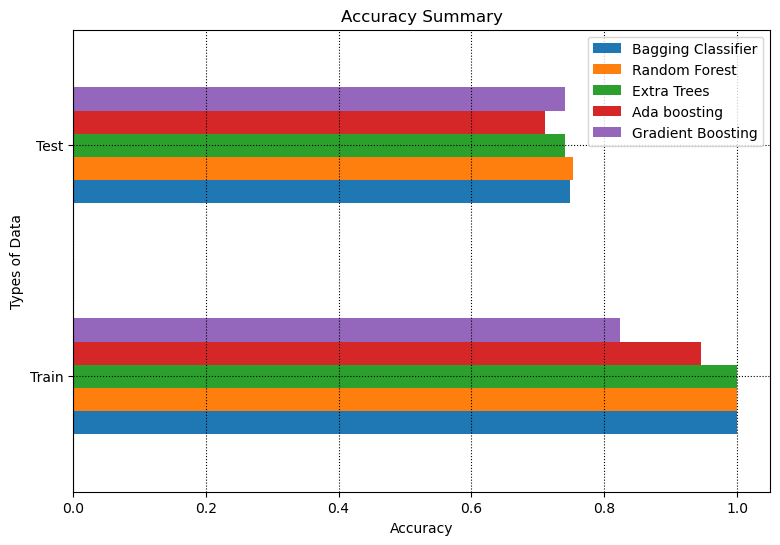

In [187]:
result.plot(kind='barh',figsize=(9,6))
plt.grid(linestyle=':',color='black')
plt.xlabel("Accuracy")
plt.ylabel("Types of Data")
plt.title("Accuracy Summary")
plt.show()